In [ ]:
%pip install json
%pip install pathlib
%pip install numpy
%pip install sys
%pip install cv2
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for Patch: filename=patch-1.16-py3-none-any.whl size=12393 sha256=632454e5296be764ddc0cad0e5ccedc1ec07cfffe8ecf4189ea86aed5b366666
  Stored in directory: c:\users\julie\appdata\local\pip\cache\wheels\9e\0b\47\01a46968b6646ca3efa32e23ed436e0c819aca97ec2c136573
Successfully built Patch
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
from pathlib import Path
import numpy as np
import sys
import openpyxl
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.widgets import Button
import ipywidgets as widgets
from IPython.display import display, clear_output
from openpyxl import load_workbook
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.formatting.rule import DataBarRule
from openpyxl.utils.dataframe import dataframe_to_rows



project_root = Path("..").resolve()
sys.path.append(str(project_root))
from Calibration.Parameters import CHAMBERS_COLORS

## Resultats sur l'ensemble des larves

In [2]:
tracking_folder = project_root / "Data"
tracking_files = list(tracking_folder.rglob("*tracking.json"))

print(len(tracking_files), "fichiers trouvés")

168 fichiers trouvés


In [3]:
sample_video = str(tracking_files[0]).replace("_tracking.json", ".mp4")
cap = cv2.VideoCapture(sample_video)
ret, frame = cap.read()
if not ret:
    video_height, video_width = 888, 930
    raise ValueError(f"Impossible d'ouvrir la vidéo {sample_video}")
else:
    video_height, video_width = frame.shape[:2]
cap.release()
print(f"Taille vidéo : {video_width} x {video_height}")

Taille vidéo : 888 x 928


In [4]:
mask_path_top = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask_path_bottom = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_bottom_painted.png"

mask_top = cv2.imread(str(mask_path_top))
mask_bottom = cv2.imread(str(mask_path_bottom))
mask_top = cv2.cvtColor(mask_top, cv2.COLOR_BGR2RGB)
mask_bottom = cv2.cvtColor(mask_bottom, cv2.COLOR_BGR2RGB)


mask_top = cv2.resize(
    mask_top,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

mask_bottom = cv2.resize(
    mask_bottom,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

## Choisir tous les labyrinthes sur lesquels on fera l'analyse

In [ ]:
lab_letters = ["A","B","C","D","E","F","G","H"]
lab_position = ["top","bottom"]

project_root = Path("..").resolve()
data_folder = project_root / "Data"

experiment_folders = sorted([f.name for f in data_folder.iterdir() if f.is_dir()])

exp_selector = widgets.SelectMultiple(
    options=experiment_folders,
    value=[experiment_folders[0]],
    description='Expériences:',
    style={'description_width':'initial'}
)

letter_selector = widgets.SelectMultiple(
    options=lab_letters,
    value=[lab_letters[0]],
    description='Labyrinthes:',
    style={'description_width':'initial'}
)

position_selector = widgets.SelectMultiple(
    options=lab_position,
    value=[lab_position[0]],
    description='Parties:',
    style={'description_width':'initial'}
)

validate_button = widgets.Button(description='Valider', button_style='success')
output = widgets.Output()

selected_tracking_files = []



In [6]:
def on_validate_clicked(b):
    global selected_tracking_files
    
    with output:
        clear_output()

        selected_experiments = exp_selector.value
        selected_letters = letter_selector.value
        selected_positions = position_selector.value

        print(f"Expérience: {selected_experiments}")
        print(f"Labyrinthes: {selected_letters}")
        print(f"Positions: {selected_positions}")

        selected_tracking_files = []
        for exp in selected_experiments:
            for letter in selected_letters:
                for pos in selected_positions:

                    Mazes_name = f"Maze_{letter}"
                    Maze_name = f"Maze_{letter}_{pos}"

                    tracking_file = data_folder / exp / "Video" / "Mazes" / Mazes_name / f"{Maze_name}_tracking.json"

                    if tracking_file.exists():
                        selected_tracking_files.append(tracking_file)
                    else:
                        print(f"Introuvable: {tracking_file}")

        print(f"\n{len(selected_tracking_files)} fichiers sélectionnés")

        if not selected_tracking_files:
            print("Aucun fichier valide")
            return

In [7]:
ui = widgets.VBox([
    exp_selector,
    widgets.HBox([letter_selector, position_selector]),
    validate_button,
    output
])
validate_button.on_click(on_validate_clicked)
display(ui)

In [8]:
selected_tracking_files

[WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_A/Maze_A_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_A/Maze_A_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_B/Maze_B_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_B/Maze_B_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_C/Maze_C_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_C/Maze_C_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_D/Maze_D_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Expe

## Lecture et obtention des données des expériences

In [9]:
excel_files = list((project_root / "Data_analysis").glob("*.xlsx"))

print(excel_files)

excel_path = excel_files[0]
df = pd.read_excel(excel_path)

df.head()

[WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data_analysis/Experimental_design.xlsx'), WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data_analysis/Results_all_files.xlsx'), WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data_analysis/Results_Final.xlsx'), WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data_analysis/Test.xlsx')]


,Commentaire,Date,Experience,Video_duration,Hour,Genotype,Age,Food,Voltage,Current,...,G3,G4,G5,G6,H1,H2,H3,H4,H5,H6
0,NaN,11032026.0,1.0,60.0,AM,Gal4,L3,corn,7.2,0.187,...,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1
1,NaN,11032026.0,2.0,60.0,PM,Gal4,L3,corn,7.2,0.187,...,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1
2,NaN,12032026.0,1.0,60.0,AM,Gal4,L3,corn,7.2,0.187,...,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1
3,NaN,12032026.0,2.0,60.0,PM,Gal4,L3,corn,7.2,0.187,...,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1
4,NaN,12032026.0,3.0,60.0,PM,Gal4,L3,corn,7.2,0.187,...,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1,Ag1


In [10]:
maze_cols = [col for col in df.columns if len(col) == 2 and col[0] in "ABCDEFGH"]

maze_df = df.melt(
    id_vars=["Date", "Experience", "Start", "Rejeted"],
    value_vars=maze_cols,
    var_name="Chamber",
    value_name="Condition"
)

maze_df = maze_df.dropna(subset=["Condition"])
maze_df["Condition"] = maze_df["Condition"].str.strip()

maze_df


,Date,Experience,Start,Rejeted,Chamber,Condition
0,11032026.0,1.0,1_4,B1_B2_B3?,A1,Ag1
1,11032026.0,2.0,2_5,B1_B2_B3?,A1,Ag1
2,12032026.0,1.0,3_6,H1_H4 visible ?,A1,Ag1
3,12032026.0,2.0,2_4,C4_C5_C6,A1,Ag1
4,12032026.0,3.0,3_6,B1_B2_B3,A1,Ag1
...,...,...,...,...,...,...
2437,26032026.0,3.0,2_5,NaN,H6,Ag1
2438,26032026.0,4.0,2_5,NaN,H6,Ag1Fru0.1
2439,26032026.0,5.0,1_4,NaN,H6,Ag2Fru1M
2440,26032026.0,6.0,1_4,NaN,H6,Ag1


In [11]:
def is_rejected(row):
    if pd.isna(row["Rejeted"]):
        return False
    
    rejected_list = str(row["Rejeted"]).replace(" ", "").split("_")
    return row["Chamber"] in rejected_list

maze_df["Rejected_clean"] = maze_df.apply(is_rejected, axis=1)

In [12]:
def is_start(row):
    if pd.isna(row["Start"]):
        return False
    
    start_nums = str(row["Start"]).split("_")
    return row["Chamber"][1] in start_nums

maze_df["Is_start"] = maze_df.apply(is_start, axis=1)
maze_df = maze_df.dropna(subset=["Date", "Experience"])

In [13]:
maze_df

,Date,Experience,Start,Rejeted,Chamber,Condition,Rejected_clean,Is_start
0,11032026.0,1.0,1_4,B1_B2_B3?,A1,Ag1,False,True
1,11032026.0,2.0,2_5,B1_B2_B3?,A1,Ag1,False,False
2,12032026.0,1.0,3_6,H1_H4 visible ?,A1,Ag1,False,False
3,12032026.0,2.0,2_4,C4_C5_C6,A1,Ag1,False,False
4,12032026.0,3.0,3_6,B1_B2_B3,A1,Ag1,False,False
...,...,...,...,...,...,...,...,...
2437,26032026.0,3.0,2_5,NaN,H6,Ag1,False,False
2438,26032026.0,4.0,2_5,NaN,H6,Ag1Fru0.1,False,False
2439,26032026.0,5.0,1_4,NaN,H6,Ag2Fru1M,False,False
2440,26032026.0,6.0,1_4,NaN,H6,Ag1,False,False


### Création d'un dictionnaire pour lier fichier Excel et vidéos

In [14]:
def extract_info_from_path(file_path):
    file_path = Path(file_path)
    
    exp = file_path.parts[-5]
    
    name = file_path.stem 
    
    parts = name.split("_")
    letter = parts[1]
    position = parts[2]
    
    return exp, letter, position

In [15]:
def extract_info_from_path(file_path):
    file_path = Path(file_path)
    
    exp_folder = file_path.parts[-5]
    
    _, exp_num, date = exp_folder.split("_")
    
    name = file_path.stem
    parts = name.split("_")
    
    letter = parts[1]
    position = parts[2]
    
    return int(exp_num), int(date), letter, position

In [16]:
tracking_info = []

for file in selected_tracking_files:
    exp_num, date, letter, position = extract_info_from_path(file)
    
    maze_numbers = [1,2,3] if position == "top" else [4,5,6]
    
    for num in maze_numbers:
        maze_id = f"{letter}{num}"
        
        tracking_info.append({
            "file": file,
            "Experience": exp_num,
            "Date": date,
            "Chamber": maze_id
        })

tracking_df = pd.DataFrame(tracking_info)

In [17]:
maze_df["Date"] = maze_df["Date"].astype(int)
maze_df["Experience"] = maze_df["Experience"].astype(int)

tracking_df["Date"] = tracking_df["Date"].astype(int)
tracking_df["Experience"] = tracking_df["Experience"].astype(int)

C:\Users\julie\AppData\Local\Temp\ipykernel_16396\2435444318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maze_df["Date"] = maze_df["Date"].astype(int)
C:\Users\julie\AppData\Local\Temp\ipykernel_16396\2435444318.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maze_df["Experience"] = maze_df["Experience"].astype(int)


In [18]:
merged_df = tracking_df.merge(
    maze_df,
    on=["Date", "Experience", "Chamber"],
    how="left"
)
merged_df = merged_df[
    ["file", "Experience", "Date", "Chamber", "Condition", "Rejected_clean", "Is_start"]
]
merged_df

,file,Experience,Date,Chamber,Condition,Rejected_clean,Is_start
0,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A1,Ag2,False,True
1,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A2,Ag1,False,False
2,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A3,Ag2,False,False
3,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A4,Ag2,False,True
4,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A5,Ag1,False,False
...,...,...,...,...,...,...,...
91,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H2,Ag1,False,False
92,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H3,Ag1,False,False
93,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H4,Ag2,False,True
94,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H5,Ag1,False,False


In [19]:
files_to_remove = (
    merged_df
    .groupby("file")["Rejected_clean"]
    .any()
)

files_to_remove = files_to_remove[files_to_remove].index.tolist()

filtered_tracking_files = [
    f for f in selected_tracking_files
    if f not in files_to_remove
]


print(f"Fichiers supprimés lors de l'expérience : {len(files_to_remove)} fichiers")


Fichiers supprimés lors de l'expérience : 2 fichiers


# Affichage de toutes les trajectoires en simultané

C:\Users\julie\AppData\Local\Temp\ipykernel_16396\3001481277.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('hsv', num_files)


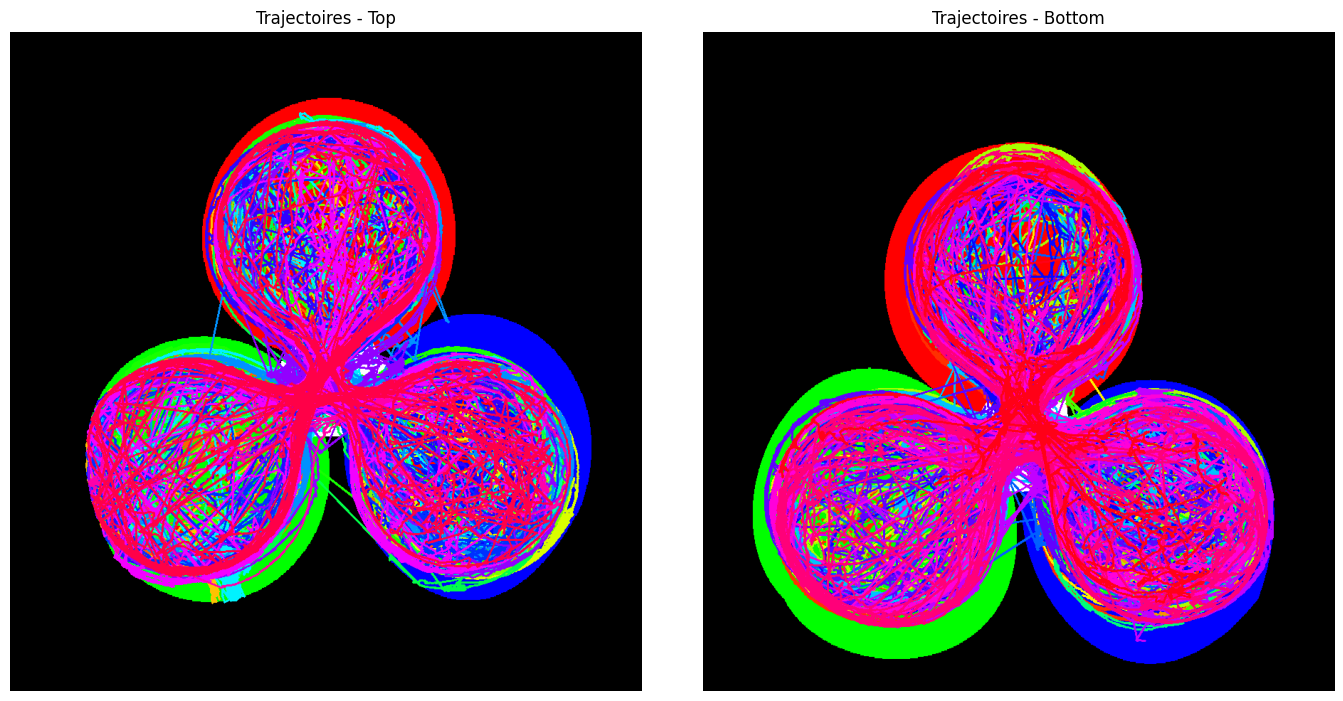

In [20]:
def plot_trajectories(selected_tracking_files, mask_top, mask_bottom, alpha=0.6, line_width=2):
    """Trace toutes les trajectoires sur les masques top et bottom."""
    
    mask_top_plot = mask_top.copy()
    mask_bottom_plot = mask_bottom.copy()
    
    num_files = len(selected_tracking_files)
    colors = cm.get_cmap('hsv', num_files)
    
    for idx, file in enumerate(selected_tracking_files):
        cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
        if cancel_file.exists():
            print(f"Vidéo ignorée (tracking annulé) : {file.stem}")
            continue
        
        with open(file) as f:
            data = json.load(f)
        
        df = data["tracking"]
        positions = [p for p in df if p["position"] is not None]
        if not positions:
            continue
        x_coords = [p["position"]["x"] for p in positions]
        y_coords = [p["position"]["y"] for p in positions]
        
        mask_plot = mask_top_plot if "_top" in str(file) else mask_bottom_plot
        color_rgb = tuple(int(255*c) for c in colors(idx)[:3])
        
        for i in range(1, len(x_coords)):
            pt1 = (int(x_coords[i-1]), int(y_coords[i-1]))
            pt2 = (int(x_coords[i]), int(y_coords[i]))
            cv2.line(mask_plot, pt1, pt2, color=color_rgb, thickness=line_width)
    
    return mask_top_plot, mask_bottom_plot


mask_top_plot, mask_bottom_plot = plot_trajectories(selected_tracking_files, mask_top, mask_bottom)

fig, axes = plt.subplots(1,2, figsize=(14,7))
axes[0].imshow(mask_top_plot)
axes[0].set_title("Trajectoires - Top")
axes[0].axis("off")

axes[1].imshow(mask_bottom_plot)
axes[1].set_title("Trajectoires - Bottom")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Choix des fichiers à conserver

In [29]:
def build_chamber_map(mask_rgb):
    """
    Convertit un masque RGB en carte d'indices de chambres.

    Parameters
    ----------
    mask_rgb : np.ndarray
        Image RGB du masque (HxWx3)

    Returns
    -------
    chamber_map : np.ndarray
        Carte 2D (HxW) avec ID des chambres
    """

    # Mapping couleurs → ID
    COLOR_TO_ID = {
        (0, 0, 255): 1,   # Chambre_1
        (0, 255, 0): 2,   # Chambre_2
        (255, 0, 0): 3,   # Chambre_3
        (255, 255, 255): 4  # Decision_zone
    }

    height, width, _ = mask_rgb.shape
    chamber_map = np.zeros((height, width), dtype=np.uint8)

    # Remplir la carte
    for color, chamber_id in COLOR_TO_ID.items():
        mask_pixels = np.all(mask_rgb == color, axis=2)
        chamber_map[mask_pixels] = chamber_id

    return chamber_map

In [30]:
class TrajectoryReviewer:
    def __init__(self, selected_tracking_files, mask_top, mask_bottom):
        self.files = selected_tracking_files
        self.mask_top = mask_top
        self.mask_bottom = mask_bottom
        self.chamber_map_top = build_chamber_map(mask_top)
        self.chamber_map_bottom = build_chamber_map(mask_bottom)

        self.idx = 0
        self.saved = []

        self.out = widgets.Output()
        self.label = widgets.HTML()

        self.btn_keep = widgets.Button(description="Garder", button_style='success')
        self.btn_skip = widgets.Button(description="Supprimer", button_style='danger')
        self.btn_back = widgets.Button(description="Retour")

        self.btn_keep.on_click(self.keep)
        self.btn_skip.on_click(self.skip)
        self.btn_back.on_click(self.back)

        self.ui = widgets.VBox([
            self.label,
            self.out,
            widgets.HBox([self.btn_keep, self.btn_skip, self.btn_back])
        ])

        display(self.ui)
        self.show()


    def compute_time_in_chambers(self, df, fps, chamber_map):
        df = df.copy()
        height, width = chamber_map.shape

        df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
        df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)

        df["chamber_id"] = [
            chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
            for x, y in zip(df["x_int"], df["y_int"])
        ]

        inverse_map = {
            0: "Outside",
            1: "Chambre_1",
            2: "Chambre_2",
            3: "Chambre_3",
            4: "Decision_zone"
        }

        df["chamber"] = df["chamber_id"].map(inverse_map)
        return df.groupby("chamber").size() / fps


    def plot_time_distribution(self, time_spent_sec):
        colors = {
            "Outside": "lightgray",
            "Chambre_1": "blue",
            "Chambre_2": "green",
            "Chambre_3": "red",
            "Decision_zone": "white"
        }

        sorted_times = time_spent_sec.sort_values()
        bar_colors = [colors[ch] for ch in sorted_times.index]

        plt.barh(sorted_times.index, sorted_times.values,
                 color=bar_colors, edgecolor='black')

        for i, v in enumerate(sorted_times.values):
            plt.text(v + 0.2, i, f"{v:.1f}s", va='center')

        plt.xlabel("Temps (s)")
        plt.title("Temps par chambre")

    def draw(self, file):
        with open(file) as f:
            data = json.load(f)

        df = pd.DataFrame(data["tracking"])
        fps = data["fps"]

        positions = [p for p in data["tracking"] if p["position"]]
        if not positions:
            return None, None, None, None

        x = [p["position"]["x"] for p in positions]
        y = [p["position"]["y"] for p in positions]

        if "_top" in str(file):
            mask = self.mask_top.copy()
            chamber_map = self.chamber_map_top
        else:
            mask = self.mask_bottom.copy()
            chamber_map = self.chamber_map_bottom

        for i in range(1, len(x)):
            cv2.line(mask, (x[i-1], y[i-1]), (x[i], y[i]), (0,0,0), 2)

        return mask, df, fps, chamber_map

    def show(self):
        while self.idx < len(self.files):
            file = self.files[self.idx]

            cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
            if cancel_file.exists():
                self.idx += 1
                continue

            img, df, fps, chamber_map = self.draw(file)

            if img is None:
                self.idx += 1
                continue

            time_spent = self.compute_time_in_chambers(df, fps, chamber_map)
            total_time = time_spent.sum()
            time_percentage = (time_spent / total_time) * 100

            with self.out:
                clear_output(wait=True)

                plt.figure(figsize=(10,5))

                plt.subplot(1,2,1)
                plt.imshow(img)
                plt.title("Trajectoire")
                plt.gca().invert_yaxis()
                plt.axis("off")

                plt.subplot(1,2,2)
                self.plot_time_distribution(time_spent)

                plt.tight_layout()
                plt.show()

            self.label.value = f"<h3>{self.idx+1}/{len(self.files)} — {file.resolve()}</h3>"
            return

        self.finish()


    def keep(self, _):
        self.saved.append(self.files[self.idx])
        self.idx += 1
        self.show()

    def skip(self, _):
        self.idx += 1
        self.show()

    def back(self, _):
        if self.idx > 0:
            self.idx -= 1
            if self.files[self.idx] in self.saved:
                self.saved.remove(self.files[self.idx])
        self.show()

    def finish(self):
        clear_output()
        print(f"Terminé : {len(self.saved)} trajectoires gardées")

In [31]:
reviewer = TrajectoryReviewer(
    selected_tracking_files,
    mask_top,
    mask_bottom
)

kept_files = reviewer.saved

In [32]:
df_kept = merged_df[merged_df["file"].isin(kept_files)]
kept_files

[WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_A/Maze_A_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_A/Maze_A_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_B/Maze_B_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_B/Maze_B_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_C/Maze_C_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_C/Maze_C_bottom_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Experiment_1_18032026/Video/Mazes/Maze_D/Maze_D_top_tracking.json'),
 WindowsPath('C:/Users/julie/Downloads/Projet CEA/Rewrite/Data/Expe

In [33]:
all_times = {}
all_distances = {}
transition_data = []

id_to_chamber = {
    0: "Outside",
    1: "Chambre_1",
    2: "Chambre_2",
    3: "Chambre_3",
    4: "Decision_zone"
}

def complete_dict(d):
    keys = ["Outside", "Chambre_1", "Chambre_2", "Chambre_3", "Decision_zone"]
    return {k: d.get(k, 0) for k in keys}


for file in kept_files:
    file_name = file

    with open(file) as f:
        data = json.load(f)

    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]

    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)

    #  TIMES
    times = reviewer.compute_time_in_chambers(df, fps, chamber_map)
    all_times[file_name] = complete_dict(times.to_dict())

    #  DISTANCES
    height, width = chamber_map.shape

    df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
    df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)

    df["chamber_id"] = [
        chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
        for x, y in zip(df["x_int"], df["y_int"])
    ]

    distances = df.groupby("chamber_id")["distance_px"].sum()

    all_distances[file_name] = complete_dict({
        id_to_chamber[ch]: dist for ch, dist in distances.items()
    })
    
    # TRANSITIONS
    last_chamber = df["chamber_id"].iloc[0]
    time_in_chamber = 1 / fps

    for chamber in df["chamber_id"].iloc[1:]:
        if chamber == last_chamber:
            time_in_chamber += 1 / fps
        else:
            transition_data.append({
                "file": file_name,
                "from": last_chamber,
                "to": chamber,
                "time_in_from": time_in_chamber
            })
            last_chamber = chamber
            time_in_chamber = 1 / fps

    
df_times = pd.DataFrame.from_dict(all_times, orient="index")
mean_times = df_times.mean()
std_times = df_times.std()
df_dist = pd.DataFrame.from_dict(all_distances, orient="index")
mean_distances = df_dist.mean()
std_distances = df_dist.std()

In [34]:
df_kept

,file,Experience,Date,Chamber,Condition,Rejected_clean,Is_start
0,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A1,Ag2,False,True
1,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A2,Ag1,False,False
2,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A3,Ag2,False,False
3,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A4,Ag2,False,True
4,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A5,Ag1,False,False
...,...,...,...,...,...,...,...
91,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H2,Ag1,False,False
92,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H3,Ag1,False,False
93,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H4,Ag2,False,True
94,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H5,Ag1,False,False


# Tracés et résultats

### Données sur les transitions entre chambres

In [ ]:
df_transitions = pd.DataFrame(transition_data)

id_to_chamber = {
    0: "Outside",
    1: "Chambre_1",
    2: "Chambre_2",
    3: "Chambre_3",
    4: "Decision_zone"
}

# Mapping + gestion des valeurs inconnues
df_transitions["from_str"] = df_transitions["from"].map(id_to_chamber).fillna("Unknown")
df_transitions["to_str"] = df_transitions["to"].map(id_to_chamber).fillna("Unknown")
df_transitions = df_transitions.merge(
    df_kept[['file', 'Chamber', 'Experience', 'Date']],
    on='file',
    how='left'
)

,file,from,to,time_in_from,from_str,to_str,Chamber,Experience,Date
0,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,2,0,1000.000000,Chambre_2,Outside,A1,1,18032026
1,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,2,0,1000.000000,Chambre_2,Outside,A2,1,18032026
2,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,2,0,1000.000000,Chambre_2,Outside,A3,1,18032026
3,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,0,2,0.166667,Outside,Chambre_2,A1,1,18032026
4,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,0,2,0.166667,Outside,Chambre_2,A2,1,18032026


In [48]:
df_transitions.columns

Index(['file', 'from', 'to', 'time_in_from', 'from_str', 'to_str', 'Chamber',
       'Experience', 'Date', 'larva_id'],
      dtype='object')

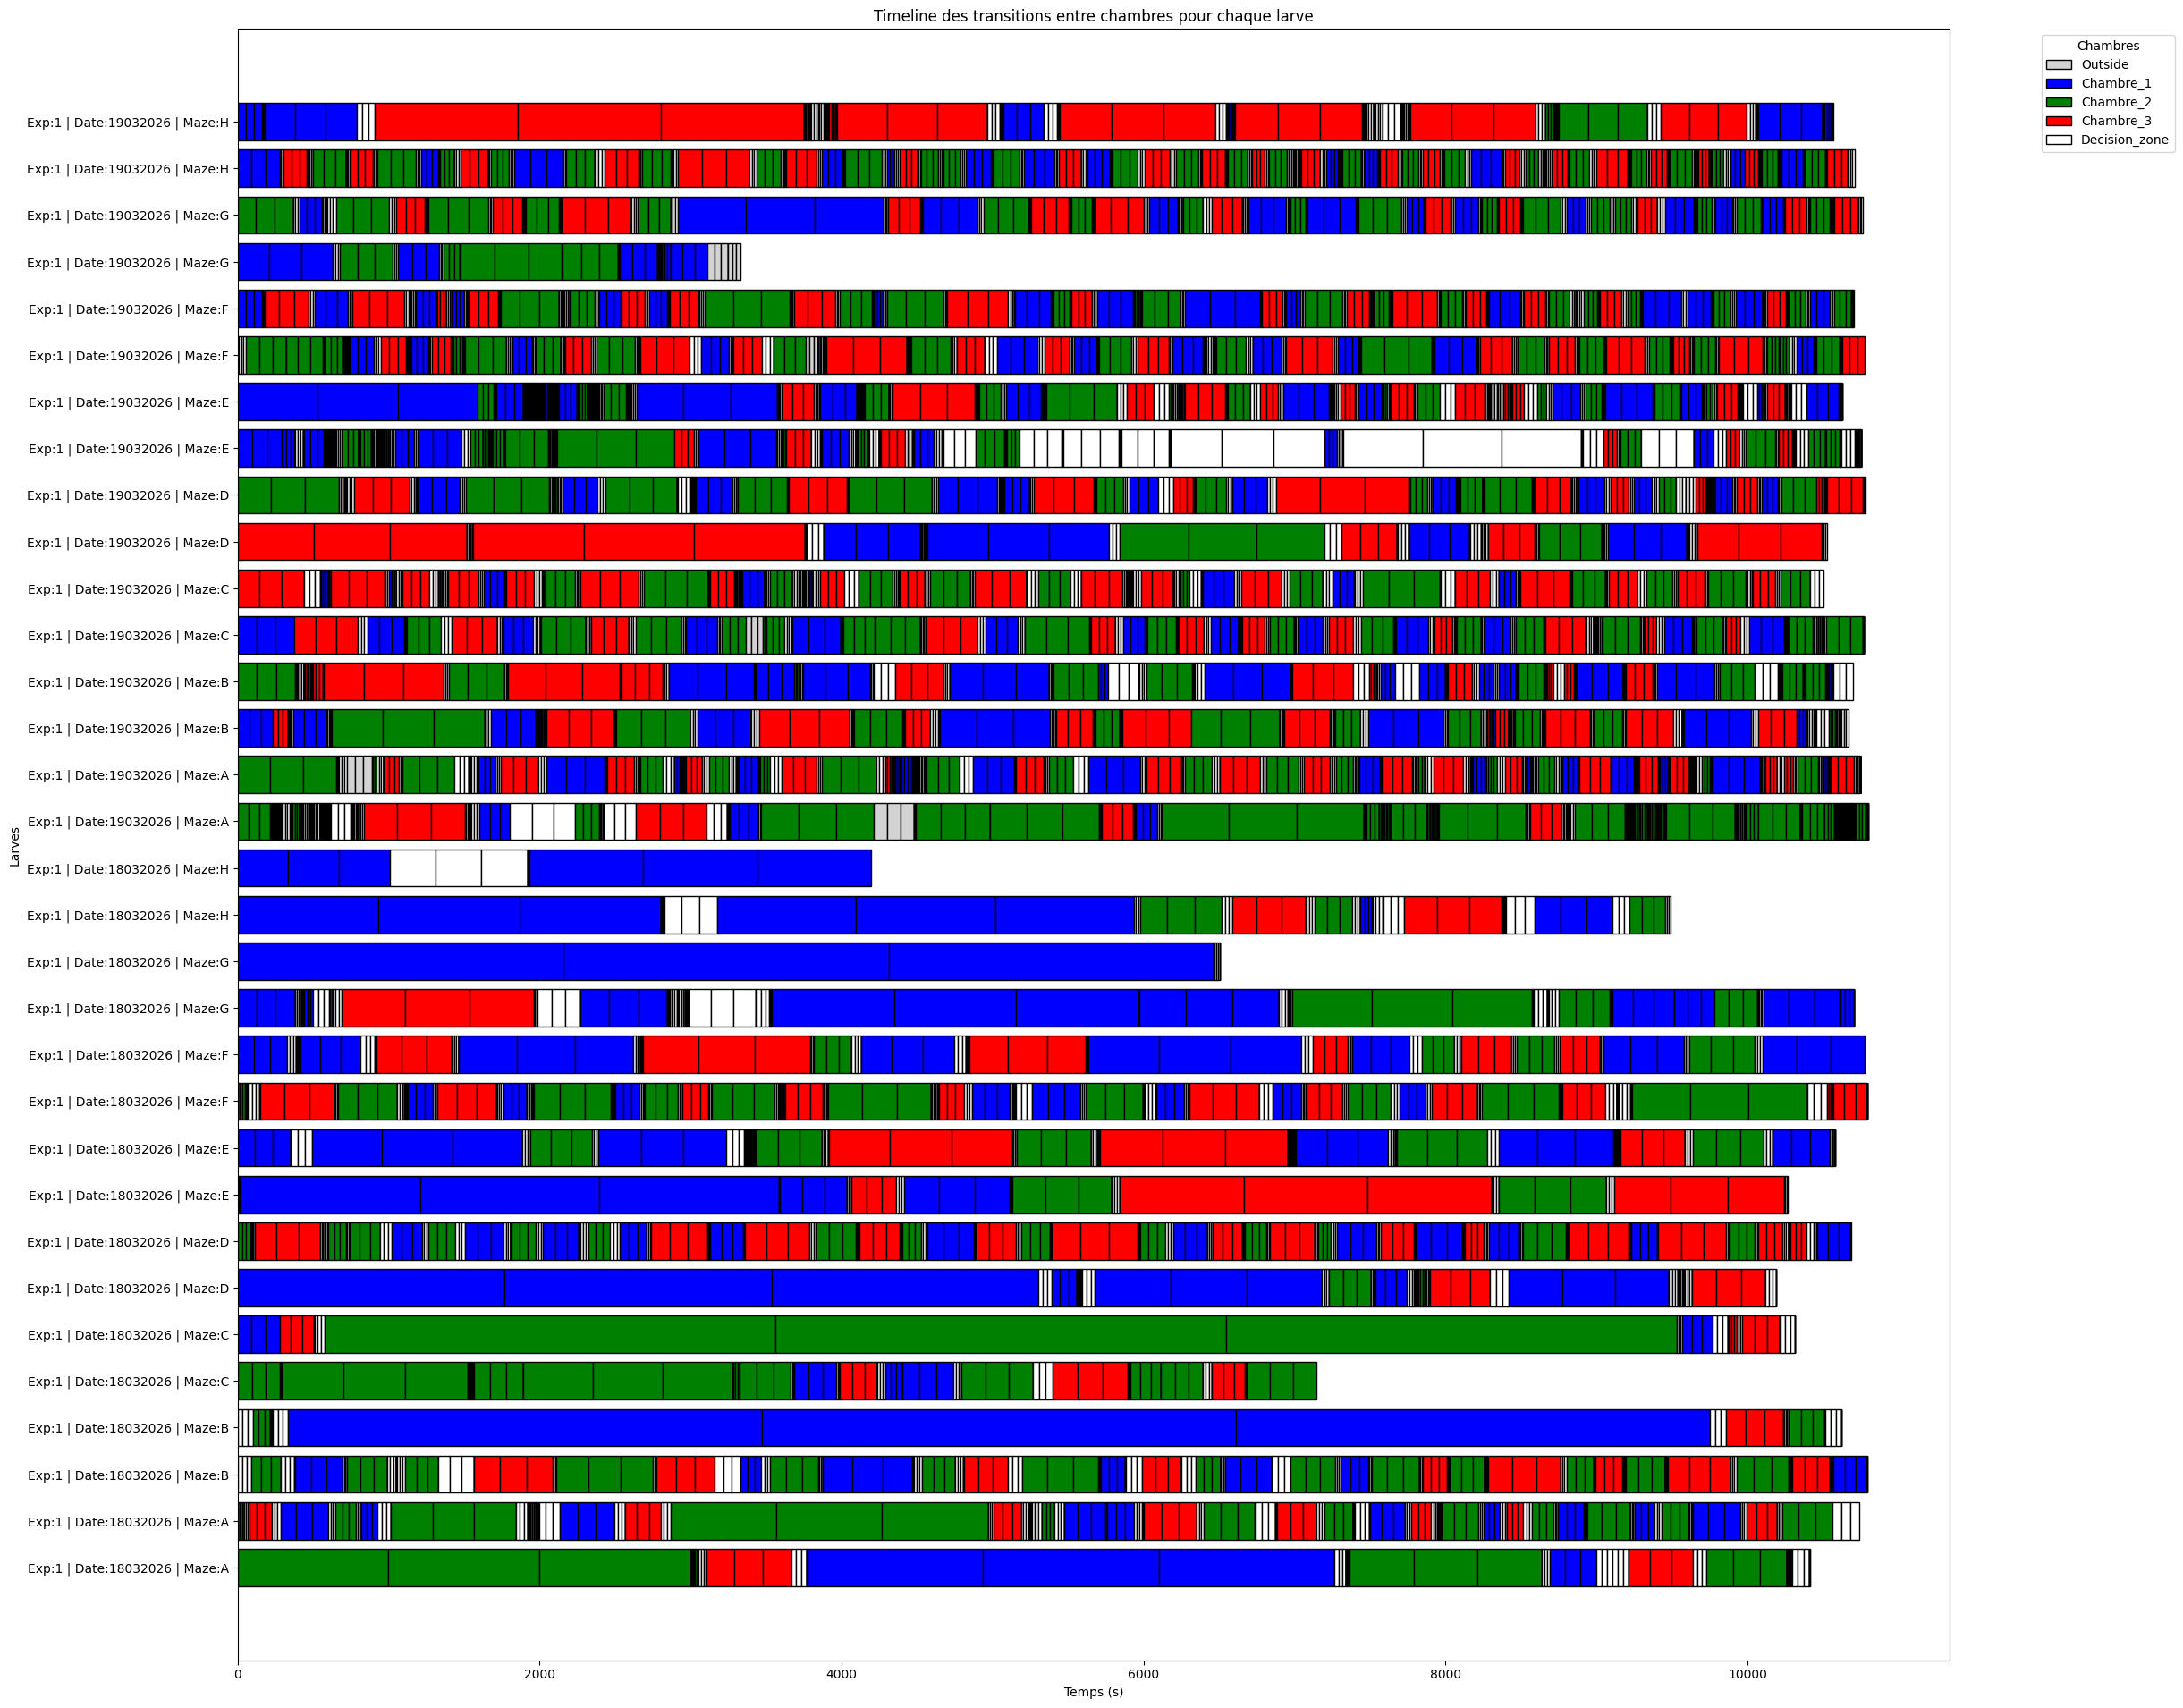

In [50]:
df_transitions["larva_id"] = df_transitions["file"].apply(lambda f: Path(f).stem)

larvae = df_transitions["file"].unique()
chamber_colors_plot = {
    "Outside": "lightgray",
    "Chambre_1": "blue",
    "Chambre_2": "green",
    "Chambre_3": "red",
    "Decision_zone": "white"
}

larva_labels = []
for larva in larvae:
    larva_transitions = df_transitions[df_transitions["file"] == larva]
    exp = larva_transitions["Experience"].iloc[0]
    date = larva_transitions["Date"].iloc[0]
    maze = larva_transitions["Chamber"].iloc[0][0]  # prend la lettre du labyrinthe
    larva_labels.append(f"Exp:{exp} | Date:{date} | Maze:{maze}")

plt.figure(figsize=(22, len(larvae)*0.6))

for i, larva in enumerate(larvae):
    larva_transitions = df_transitions[df_transitions["file"] == larva]
    t_start = 0
    for _, row in larva_transitions.iterrows():
        t_end = t_start + row["time_in_from"]
        plt.barh(
            i, 
            t_end - t_start, 
            left=t_start, 
            color=chamber_colors_plot.get(row["from_str"], "gray"), 
            edgecolor="black"
        )
        t_start = t_end

plt.yticks(range(len(larvae)), larva_labels)
plt.xlabel("Temps (s)")
plt.ylabel("Larves")
plt.title("Timeline des transitions entre chambres pour chaque larve")
plt.tight_layout()

legend_elements = [Patch(facecolor=color, edgecolor='black', label=ch) 
                   for ch, color in chamber_colors_plot.items()]
plt.legend(handles=legend_elements, title="Chambres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Données sur la distance moyenne parcourue et le temps moyen dans les chambres indépendemment des conditions
### ATTENTION ne pas regarder si les conditions dans les chambres changent.

In [51]:
df_kept = merged_df[merged_df["file"].isin(kept_files)]

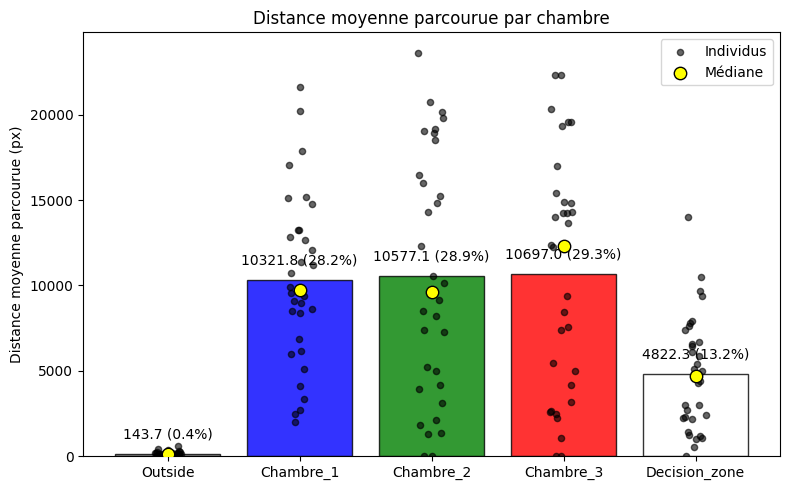

In [52]:
chambers = mean_distances.index.tolist()
means = mean_distances.values
bar_colors = [CHAMBERS_COLORS.get(ch, "gray") for ch in chambers]
stds = std_distances.values

total_mean = means.sum()

plt.figure(figsize=(8,5))
bars = plt.bar(
    chambers, means,
    color=bar_colors, edgecolor='black',
    alpha=0.8, capsize=5
)

for bar, mean in zip(bars, means):
    percent = mean / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(stds)*0.1,
        f"{mean:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom'
    )

df_dist = pd.DataFrame.from_dict(all_distances, orient="index")

points_added = False
median_added = False
for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    x = np.full(len(values), i) + np.random.uniform(-0.1, 0.1, len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3, label="Individus" if not points_added else "")
    points_added = True

    median = np.median(values)
    plt.scatter(i, median, color='yellow', edgecolor='black', s=80, zorder=4, label="Médiane" if not median_added else "")
    median_added = True
    

plt.ylabel("Distance moyenne parcourue (px)")
plt.title("Distance moyenne parcourue par chambre")

plt.legend()
plt.tight_layout()
plt.show()

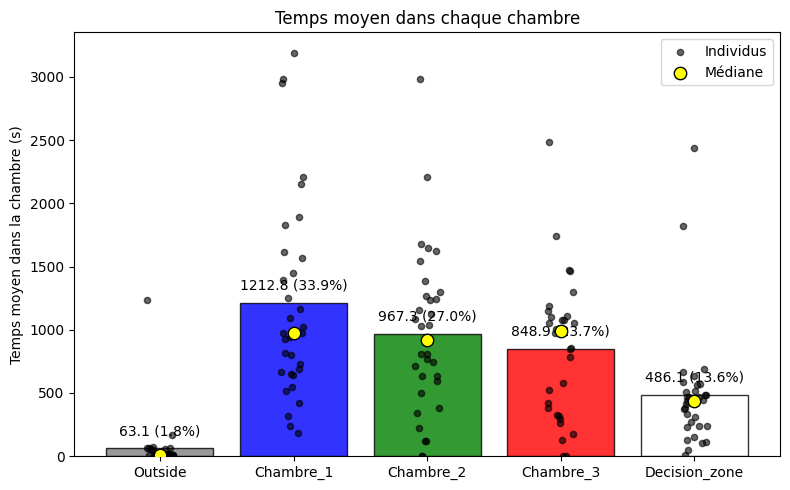

In [53]:
chambers = mean_times.index.tolist()
means = mean_times.values
bar_colors = [CHAMBERS_COLORS.get(ch, "gray") for ch in chambers]
stds = std_times.values

total_mean = means.sum()

plt.figure(figsize=(8,5))
bars = plt.bar(
    chambers, means,
    color=bar_colors, edgecolor='black',
    alpha=0.8, capsize=5
)

for bar, mean in zip(bars, means):
    percent = mean / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(stds)*0.1,
        f"{mean:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom'
    )

df_dist = pd.DataFrame.from_dict(all_times, orient="index")

points_added = False
median_added = False
for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    x = np.full(len(values), i) + np.random.uniform(-0.1, 0.1, len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3, label="Individus" if not points_added else "")
    points_added = True

    median = np.median(values)
    plt.scatter(i, median, color='yellow', edgecolor='black', s=80, zorder=4, label="Médiane" if not median_added else "")
    median_added = True
    

plt.ylabel("Temps moyen dans la chambre (s)")
plt.title("Temps moyen dans chaque chambre")

plt.legend()
plt.tight_layout()
plt.show()

### Données sur la distance moyenne et sur le temps moyen en fonction des conditions

In [54]:
merged_df

,file,Experience,Date,Chamber,Condition,Rejected_clean,Is_start
0,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A1,Ag2,False,True
1,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A2,Ag1,False,False
2,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A3,Ag2,False,False
3,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A4,Ag2,False,True
4,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,18032026,A5,Ag1,False,False
...,...,...,...,...,...,...,...
91,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H2,Ag1,False,False
92,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H3,Ag1,False,False
93,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H4,Ag2,False,True
94,C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...,1,19032026,H5,Ag1,False,False


In [55]:
def map_chamber_name(chamber):
    if len(chamber) >= 2 and chamber[0] in lab_letters:

        chamber_id = int(chamber[1])
        if chamber_id > 3:
            chamber_id = ((chamber_id - 1) % 3) + 1
        return f"Chambre_{chamber_id}"

    elif chamber == "Decision_zone":
        return "Decision_zone"
    elif chamber == "Outside":
        return "Outside"
    else:
        return "Unknown"
    
    
all_files_df = []
for file in kept_files:
    merged_df_file = merged_df[merged_df["file"] == file].copy()
    merged_df_file = merged_df_file[["file", "Experience", "Date", "Chamber", "Condition", "Rejected_clean", "Is_start"]]

    # Mapping des chambres A1-A6
    merged_df_file["Chamber_name"] = merged_df_file["Chamber"].apply(map_chamber_name)

    # Ajouter les temps correspondants depuis all_times
    merged_df_file["Time_in_chamber"] = merged_df_file["Chamber_name"].apply(
        lambda ch: all_times[file].get(ch, 0)
    )
    
    merged_df_file["Distance_in_chamber"] = merged_df_file["Chamber_name"].apply(
        lambda ch: all_distances[file].get(ch, 0)
    )

    # Ajouter Outside et Decision_zone sans condition
    for special_ch in ["Outside", "Decision_zone"]:
        merged_df_file = pd.concat([
            merged_df_file,
            pd.DataFrame({
                "file": [file],
                "Experience": [merged_df_file["Experience"].iloc[0]],
                "Date": [merged_df_file["Date"].iloc[0]],
                "Chamber": [special_ch],
                "Condition": [None],  # pas de condition
                "Rejected_clean": [False],
                "Is_start": [False],
                "Chamber_name": [special_ch],
                "Time_in_chamber": [all_times[file].get(special_ch, 0)],
                "Distance_in_chamber": [all_distances[file].get(special_ch, 0)]
            })
        ], ignore_index=True)
    all_files_df.append(merged_df_file)



In [56]:
all_files_df

[                                                file  Experience      Date  \
 0  C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...           1  18032026   
 1  C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...           1  18032026   
 2  C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...           1  18032026   
 3  C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...           1  18032026   
 4  C:\Users\julie\Downloads\Projet CEA\Rewrite\Da...           1  18032026   
 
          Chamber Condition  Rejected_clean  Is_start   Chamber_name  \
 0             A1       Ag2           False      True      Chambre_1   
 1             A2       Ag1           False     False      Chambre_2   
 2             A3       Ag2           False     False      Chambre_3   
 3        Outside      None           False     False        Outside   
 4  Decision_zone      None           False     False  Decision_zone   
 
    Time_in_chamber  Distance_in_chamber  
 0      1395.666667          9355.284697  
 1  

In [57]:
wb = load_workbook(excel_path, data_only=True)
ws = wb.active

condition_colors = {}

for col in range(15, ws.max_column + 1):
    for row in range(2, ws.max_row + 1):  # lignes de données
        cell = ws.cell(row=row, column=col)
        val = cell.value
        if val is not None:
            fill = cell.fill
            if fill.start_color and fill.start_color.rgb:
                rgb = fill.start_color.rgb  # format 'FFRRGGBB'
                hex_color = "#" + rgb[-6:]  # enlever l'alpha FF si présent
                # garder la couleur unique pour chaque condition
                if val not in condition_colors:
                    condition_colors[val] = hex_color

print(condition_colors)

{'Ag1': '#FFFF00', 'Ag2': '#FFC000', 'Ag1Fru0.1': '#92D050', 'Ag1Fru1M': '#FF0000', 'Ag2Fru0.1': '#00B050', 'Ag2Fru1M': '#E36C09', '²': '#000000'}


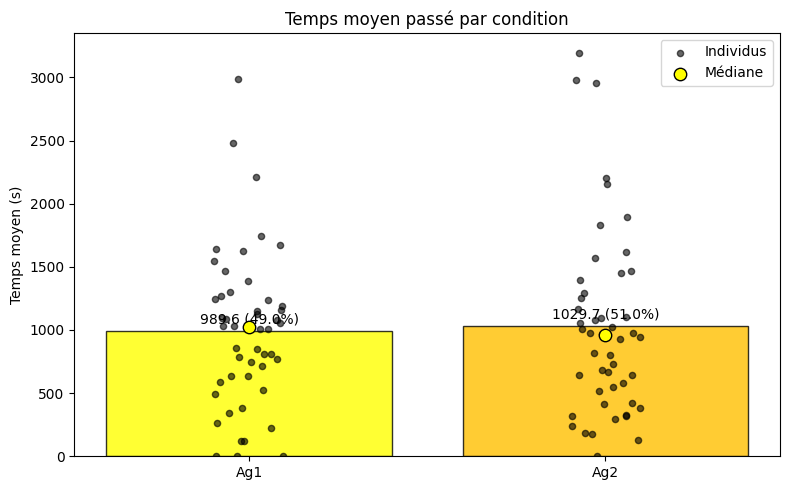

In [58]:
df_all = pd.concat(all_files_df, ignore_index=True)
df_conditions = df_all.dropna(subset=['Condition'])

mean_times = df_conditions.groupby('Condition')['Time_in_chamber'].mean()
std_times = df_conditions.groupby('Condition')['Time_in_chamber'].std()

conditions = mean_times.index.tolist()
x = np.arange(len(conditions))

total_mean = mean_times.sum()  # <- total pourcentage

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    mean_times.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, mean_val in enumerate(mean_times.values):
    percent = mean_val / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        x[i],
        mean_val + max(std_times.values)*0.05,
        f"{mean_val:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom',
        fontsize=10
    )

points_added = False
median_added = False

for i, cond in enumerate(conditions):
    values = df_conditions[df_conditions['Condition'] == cond]['Time_in_chamber'].values
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(values))
    plt.scatter(x[i] + jitter, values, color='black', alpha=0.6, s=20, zorder=3,
                label="Individus" if not points_added else "")
    points_added = True

    median_val = np.median(values)
    plt.scatter(x[i], median_val, color='yellow', edgecolor='black', s=80, zorder=4,
                label="Médiane" if not median_added else "")
    median_added = True

plt.xticks(x, conditions)
plt.ylabel("Temps moyen (s)")
plt.title("Temps moyen passé par condition")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\julie\AppData\Local\Temp\ipykernel_16396\1344973305.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


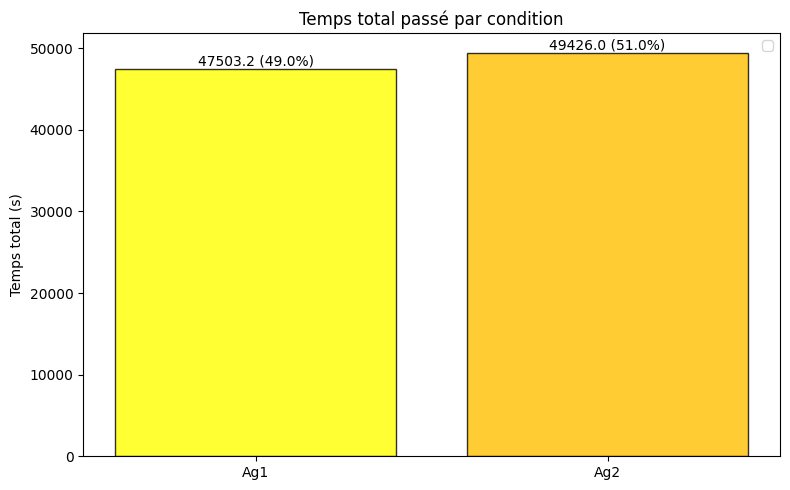

In [59]:
df_all = pd.concat(all_files_df, ignore_index=True)
df_conditions = df_all.dropna(subset=['Condition'])

sum_times = df_conditions.groupby('Condition')['Time_in_chamber'].sum()
std_times = df_conditions.groupby('Condition')['Time_in_chamber'].std()

conditions = sum_times.index.tolist()
x = np.arange(len(conditions))

total_time = sum(sum_times.values)

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    sum_times.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, sum_val in enumerate(sum_times.values):
    percent = sum_val / total_time * 100
    plt.text(
        x[i],
        sum_val + max(std_times.values)*0.05,
        f"{sum_val:.1f} ({percent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(x, conditions)
plt.ylabel("Temps total (s)")
plt.title("Temps total passé par condition")
plt.legend()
plt.tight_layout()
plt.show()

# Enregistrement des résultats dans un fichier excel

Entrez le nom de votre fichier

In [60]:
# Nom du fichier de sortie
file_name = "Results_all_files"

KeyError: "['From', 'To'] not in index"

In [ ]:
output_excel = project_root / "Data_analysis" / f"{file_name}.xlsx"
all_files_df = pd.concat(all_files_df, ignore_index=True)

# Couleurs pour les chambres
chamber_colors = {
    "Outside": "D3D3D3",
    "Chambre_1": "0000FF",
    "Chambre_2": "00FF00",
    "Chambre_3": "FF0000",
    "Decision_zone": "FFFFFF"
}

# --- 1. Résumé par chambre ---
summary_chamber = all_files_df.groupby('Chamber_name').agg(
    Mean_time_s=('Time_in_chamber', 'mean'),
    Std_time_s=('Time_in_chamber', 'std'),
    Median_time_s=('Time_in_chamber', 'median'),
    Mean_distance_px=('Distance_in_chamber', 'mean'),
    Std_distance_px=('Distance_in_chamber', 'std'),
    Median_distance_px=('Distance_in_chamber', 'median')
).reset_index()

total_time = summary_chamber['Mean_time_s'].sum()
total_distance = summary_chamber['Mean_distance_px'].sum()

summary_chamber['Percent_time'] = summary_chamber['Mean_time_s'] / total_time * 100
summary_chamber['Percent_distance'] = summary_chamber['Mean_distance_px'] / total_distance * 100

# --- 2. Résumé par condition ---
df_conditions = all_files_df.dropna(subset=['Condition'])

summary_condition = df_conditions.groupby('Condition').agg(
    Mean_time_s=('Time_in_chamber', 'mean'),
    Std_time_s=('Time_in_chamber', 'std'),
    Median_time_s=('Time_in_chamber', 'median'),
    Mean_distance_px=('Distance_in_chamber', 'mean'),
    Std_distance_px=('Distance_in_chamber', 'std'),
    Median_distance_px=('Distance_in_chamber', 'median')
).reset_index()

total_time_cond = summary_condition['Mean_time_s'].sum()
total_distance_cond = summary_condition['Mean_distance_px'].sum()

summary_condition['Percent_time'] = summary_condition['Mean_time_s'] / total_time_cond * 100
summary_condition['Percent_distance'] = summary_condition['Mean_distance_px'] / total_distance_cond * 100

# --- 3. Transitions ---
transitions_df_export = df_transitions[["larva_id", "from_str", "to_str", "time_in_from"]].copy()

# --- 4. Liste des fichiers conservés ---
files_df = pd.DataFrame({"Kept_files": [str(f) for f in kept_files]})

# --- 5. Données par fichier ---
per_file_data = []
for file in kept_files:
    df_file = all_files_df[all_files_df["file"] == file]
    for _, row in df_file.iterrows():
        per_file_data.append({
            "File": str(file),
            "Chamber": row["Chamber_name"],
            "Condition": row.get("Condition", None),
            "Time_s": row["Time_in_chamber"],
            "Distance_px": row["Distance_in_chamber"]
        })

per_file_df = pd.DataFrame(per_file_data)

# --- Création Excel ---
wb = Workbook()
wb.remove(wb.active)

def add_sheet_from_df(wb, df, name):
    ws = wb.create_sheet(name)
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=True), 1):
        for c_idx, value in enumerate(row, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=value)
            cell.alignment = Alignment(horizontal='center', vertical='center')
            if r_idx > 1 and df.columns[c_idx-1] in ["Chamber_name", "Chamber", "From_chamber", "To_chamber", "Condition"]:
                color = chamber_colors.get(value, None)
                if color:
                    cell.fill = PatternFill(start_color=color, end_color=color, fill_type="solid")
            if r_idx == 1:
                cell.font = Font(bold=True)

    thin = Side(border_style="thin", color="000000")
    for row_cells in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        for cell in row_cells:
            cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # Data bars pour les colonnes numériques
    for col_name in df.select_dtypes(include=np.number).columns:
        col_idx = df.columns.get_loc(col_name) + 1
        db_rule = DataBarRule(start_type="min", end_type="max", color="63C384", showValue="None")
        ws.conditional_formatting.add(
            f"{ws.cell(row=2,column=col_idx).coordinate}:{ws.cell(row=ws.max_row,column=col_idx).coordinate}",
            db_rule
        )

# Ajouter toutes les feuilles
add_sheet_from_df(wb, summary_chamber, "Summary_by_Chamber")
add_sheet_from_df(wb, summary_condition, "Summary_by_Condition")
add_sheet_from_df(wb, transitions_df_export, "Transitions")
add_sheet_from_df(wb, files_df, "Kept_Files")
add_sheet_from_df(wb, per_file_df, "Per_File_Data")

# Ajuster largeur des colonnes
for ws in wb.worksheets:
    for col in ws.columns:
        max_length = max(len(str(c.value)) if c.value is not None else 0 for c in col) + 2
        ws.column_dimensions[col[0].column_letter].width = max_length

wb.save(output_excel)
print(f"Fichier Excel complet créé : {output_excel}")

Fichier Excel complet créé : C:\Users\julie\Downloads\Projet CEA\Rewrite\Data_analysis\Results_all_files.xlsx
